# NB09e: Landuse Plausibility Filter v3 (with NB12 OOF predictions schema) (v2 parquets + accumulator products)## Pipeline positionNB05a/b (v2 parquets) + NB03e (accumulators) -> NB06-NB09a-d -> **NB09e** -> NB10 (future)## PurposeEvaluate plausibility signals **directly against UNOSAT ground truth** (damage_binary),independent of any ML model. Answers: "do landuse transition, NDVI loss, COH drop,building size, SWIR accumulator anomaly, Mahalanobis accumulator distance, and persistenturban loss accumulator independently predict damage?"## Data sources (v2 manifest keys)- `composite_prepost_landuse` A10 -> pre/post landuse mode per building- `scene_indices` A5 (long) -> NDVI pre/post via battle-date aggregation- `coh_drop` A14 -> derived COH drop stats (max_drop_mean, etc)- `ms_change` A20 -> SWIR z-score + NBR anomaly accumulator (per NB03e)- `ms_maha` A21 -> Mahalanobis distance accumulator (per NB03e)- `lu_change` A22 -> persistent urban landuse loss accumulator (per NB03e)- `bda_buildings_t{tier}.parquet` -> labels + area_m2## Plausibility signals1. Landuse transition (A10: urban -> bare_soil/vegetation = plausible damage)2. NDVI change (A5 scene_indices: vegetation loss)3. Building size (< 50 m2 unreliable at 10m)4. Coherence drop (A14: max_drop_mean / running_min_mean)5. **NEW**: MS SWIR accumulator (A20 swir_rise_count, swir_z_running_max, nbr_anomaly_count)6. **NEW**: MS Mahalanobis accumulator (A21 mahalanobis_running_max, exceedance_count)7. **NEW**: Persistent landuse loss accumulator (A22 urban_retained, loss_fraction)8. Combined plausibility score (weighted sum)## Design decisionPrevious versions evaluated plausibility as post-processing on NB09a RF predictions.v2 evaluates against UNOSAT directly. v2 also adds accumulator-based signals from NB03ethat integrate over ALL observations (not just pre/post snapshots) - expected to carrymore damage signal for cities with good observation density.

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


# CELL 3: NB09e v2 CONFIG + GLOBAL SETUP

In [1]:
# @title CELL 3: NB09e v2 CONFIG + GLOBAL SETUP
TIER_SELECTION = [0,1,2]
CITY_SELECTION = None
REQUIRE_UNOSAT = True

import platform, os
os.environ['PROJ_DATA'] = os.path.expanduser('~/miniconda3/envs/bda/share/proj')
os.environ['PROJ_LIB'] = os.environ['PROJ_DATA']
import pyproj
pyproj.datadir.set_data_dir(os.environ['PROJ_DATA'])

if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())

BDA GLOBAL SETUP
Started: 2026-04-25 00:30:34
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     910.4/7452.0 GB (6541.7 GB free)
  GDrive (F:)     1210.7/3726.0 GB (2515.3 GB free)
  Local data      11559.9/14901.9 GB (3341.9 GB free)
  Data stack      1210.7/3726.0 GB (2515.3 GB free)
  WSL ext4        68.6/1006.9 GB (887.1 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

# CELL S0: LOAD MANIFEST + BUILDINGS + NB13/NB08 RESULTS + HELPERSLoads v2 manifest, buildings, NB13 consolidated CSV, NB08a/b CSVs. Defines `load_v2()`.Pre-computes `df_bldg` (with damage_binary, area_m2, tier) shared by all plausibility cells.

In [2]:
# @title CELL S0: NB09e v2 LOAD MANIFEST + BUILDINGS + HELPERS
import sys, importlib, re, gc, json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, average_precision_score)
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("CELL S0: NB09e v2 LOAD MANIFEST + BUILDINGS + HELPERS")
print("=" * 70)

_nb_dir = str(NOTEBOOKS_DIR)
if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

# --- resolve cities --------------------------------------------------
CITIES_TO_PROCESS, _battle_dates = resolve_cities(
    tier_selection=TIER_SELECTION,
    city_selection=[CITY_SELECTION] if isinstance(CITY_SELECTION, str) else CITY_SELECTION,
    require_unosat=REQUIRE_UNOSAT,
)
print(f"  Cities: {len(CITIES_TO_PROCESS)}")

# --- load v2 manifest -------------------------------------------------
MANIFEST_V2_PATH = DATASET_ROOT_V2 / 'parquet_manifest.json'
if not MANIFEST_V2_PATH.exists():
    raise FileNotFoundError(f"V2 manifest not found: {MANIFEST_V2_PATH}")
with open(MANIFEST_V2_PATH) as _f:
    MANIFEST = json.load(_f)
print(f"  Manifest: {MANIFEST_V2_PATH}")
print(f"  Parquets in manifest: {len(MANIFEST['parquets'])}")

# --- load buildings (v2) ----------------------------------------------
_tiers = TIER_SELECTION if isinstance(TIER_SELECTION, list) else [0, 1, 2]
_bldg_pattern = str(DATASET_ROOT_V2 / 'bda_buildings_t{tier}.parquet')
df_bldg = load_tier_parquets(_bldg_pattern, _tiers)
df_bldg = df_bldg[df_bldg['city'].isin(CITIES_TO_PROCESS)].copy()
df_bldg = df_bldg[df_bldg['damage_binary'] >= 0].copy()
n_dmg = int((df_bldg['damage_binary'] == 1).sum())
n_und = int((df_bldg['damage_binary'] == 0).sum())
print(f"  Buildings: {len(df_bldg)} (damaged={n_dmg}, undamaged={n_und})")
print(f"  Building cols: area_m2={'area_m2' in df_bldg.columns}, tier={'tier' in df_bldg.columns}")

TARGET_COL = 'damage_binary'

# ---- NB12 overlap-analysis: canonical OOF predictions schema ----
import hashlib as _hashlib, datetime as _dt
from scipy.stats import rankdata as _rankdata
EXPERIMENT_ID = _dt.datetime.now().strftime('%Y%m%d_%H%M%S') + '_' + _hashlib.md5(
    f'nb09e_{TIER_SELECTION}_{REQUIRE_UNOSAT}'.encode()).hexdigest()[:6]
print(f"  EXPERIMENT_ID: {EXPERIMENT_ID}")

OOF_DIR = (RESULTS_ROOT / 'nb09e_v2' / 'oof_predictions')
OOF_DIR.mkdir(parents=True, exist_ok=True)

def save_oof_unsupervised(building_ids, cities, y_true, scores, model_id,
                          variant_id='', threshold=0.5):
    '''Unsupervised: rank-normalize raw scores to [0,1], threshold at median; fold_id=0.'''
    scores = np.asarray(scores, dtype=float)
    valid = ~np.isnan(scores)
    if valid.sum() == 0:
        print(f"    [save_oof_unsup] skipped {model_id}: no valid scores")
        return None
    s = scores[valid]
    yt = np.asarray(y_true).astype(int)[valid]
    bid = np.asarray(building_ids)[valid]
    cty = np.asarray(cities)[valid]
    y_proba = _rankdata(s) / len(s)
    yp = (y_proba >= threshold).astype(int)
    cm_class = np.where(yt == 1,
                        np.where(yp == 1, 'TP', 'FN'),
                        np.where(yp == 1, 'FP', 'TN'))
    oof_df = pd.DataFrame({
        'building_id':   bid,
        'city':          cty,
        'fold_id':       np.zeros(len(yt), dtype=int),
        'y_true':        yt,
        'y_proba':       y_proba.astype(float),
        'y_pred':        yp,
        'cm_class':      cm_class,
        'model_id':      model_id,
        'experiment_id': EXPERIMENT_ID,
        'variant_id':    variant_id,
        'is_final':      False,
    })
    out = OOF_DIR / f'oof_{model_id}__{EXPERIMENT_ID}.parquet'
    oof_df.to_parquet(out, index=False)
    n_tp = int((cm_class == 'TP').sum()); n_fn = int((cm_class == 'FN').sum())
    n_fp = int((cm_class == 'FP').sum()); n_tn = int((cm_class == 'TN').sum())
    print(f"    saved oof -> {out.name}  TP={n_tp} FN={n_fn} FP={n_fp} TN={n_tn}")
    return out

# --- leakage patterns (exclude from standalone signals) --------------
LEAKAGE_EXCLUDE_PATTERNS = [
    r's1__coh__scenes_observed',
    r's2__obs_count__',
    r's2__qa__cloud_freq__',
    r's2__visibility__cloud__freq',
    r's1__coh__scenes_observed_max',
    r's1__coh__scenes_observed_mean',
    r's1__coh__scenes_observed_std',
    r's2__scenes_observed',
    r'scenes_observed',
]
_LEAKAGE_RE = [re.compile(p) for p in LEAKAGE_EXCLUDE_PATTERNS]

def drop_leakage(cols):
    return [c for c in cols if not any(rx.search(c) for rx in _LEAKAGE_RE)]


# --- v2 manifest-driven loader ---------------------------------------
def load_v2(manifest_key, tiers=None, columns=None):
    '''Load a v2 parquet by manifest key, filter to CITIES_TO_PROCESS,
    merge labels via df_bldg if not present. Returns merged df.'''
    if manifest_key not in MANIFEST['parquets']:
        raise KeyError(f"Manifest key not found: {manifest_key}")
    info = MANIFEST['parquets'][manifest_key]
    fname_tmpl = Path(info['pattern']).name
    tiers = tiers if tiers is not None else _tiers

    frames = []
    for t in tiers:
        pf = DATASET_ROOT_V2 / fname_tmpl.format(tier=t)
        if not pf.exists():
            print(f"  WARNING: {pf.name} not found, skipping tier {t}")
            continue
        if columns is not None:
            join_cols = info.get('join_keys', ['city', 'building_id'])
            read_cols = list(dict.fromkeys(join_cols + list(columns)))
            try:
                df_t = pd.read_parquet(pf, columns=read_cols)
            except Exception:
                df_t = pd.read_parquet(pf)
                keep = [c for c in read_cols if c in df_t.columns]
                df_t = df_t[keep]
        else:
            df_t = pd.read_parquet(pf)
        frames.append(df_t)
    if not frames:
        raise FileNotFoundError(f"No v2 parquets found for key={manifest_key} tiers={tiers}")
    df = pd.concat(frames, ignore_index=True)
    del frames

    df = df.loc[:, ~df.columns.duplicated()]
    df = df[df['city'].isin(CITIES_TO_PROCESS)].copy()
    if TARGET_COL not in df.columns:
        df = df.merge(df_bldg[['building_id', 'city', TARGET_COL]].drop_duplicates(),
                      on=['building_id', 'city'], how='inner')
    df = df[df[TARGET_COL] >= 0].copy()
    df = df.loc[:, ~df.columns.duplicated()]
    print(f"  load_v2('{manifest_key}'): {len(df):,} rows, {df.shape[1]} cols, {df['city'].nunique()} cities")
    return df


# --- standalone-signal scorer ----------------------------------------
def score_signal(values, y_true, label, higher_is_damage=True):
    '''Compute AUC, AP, MWU p-value, medians for a standalone signal.
    Returns dict or None if insufficient data.'''
    mask = ~pd.isna(values)
    if mask.sum() < 50:
        return None
    vals = np.asarray(values)[mask]
    yt = np.asarray(y_true)[mask]
    if len(np.unique(yt)) < 2:
        return None
    score_for_auc = vals if higher_is_damage else -vals
    auc = roc_auc_score(yt, score_for_auc)
    ap = average_precision_score(yt, score_for_auc)
    dmg_vals = vals[yt == 1]
    und_vals = vals[yt == 0]
    if len(dmg_vals) < 10 or len(und_vals) < 10:
        return None
    stat, pval = mannwhitneyu(dmg_vals, und_vals, alternative='two-sided')
    return {
        'signal': label, 'higher_is_damage': higher_is_damage,
        'auc': round(float(auc), 4), 'avg_precision': round(float(ap), 4),
        'mwu_pvalue': float(pval),
        'damaged_median': round(float(np.median(dmg_vals)), 4),
        'undamaged_median': round(float(np.median(und_vals)), 4),
        'delta_median': round(float(np.median(dmg_vals) - np.median(und_vals)), 4),
        'n_valid': int(mask.sum()),
        'score_for_auc': score_for_auc,
        'y_true_valid': yt,
        'mask': mask,
    }


# --- NB13 + NB08 context CSVs ----------------------------------------
nb13_dir = RESULTS_ROOT / 'nb13'
nb13_csv = sorted(nb13_dir.glob('consolidated_experiments_*.csv')) if nb13_dir.exists() else []
NB13_DF = None
if nb13_csv:
    NB13_DF = pd.read_csv(nb13_csv[-1])
    print(f"  NB13 consolidated: {nb13_csv[-1].name} ({len(NB13_DF)} experiments)")
    if 'auc' in NB13_DF.columns:
        best = NB13_DF.loc[NB13_DF['auc'].idxmax()]
        print(f"    Best overall: {best.get('experiment_name','?')} AUC={best['auc']:.4f} ({best.get('notebook','?')})")
else:
    print(f"  NB13 consolidated CSV not found at {nb13_dir}")

nb08a_dir = RESULTS_ROOT / 'nb08a'
nb08a_csv = sorted((nb08a_dir / 'cell_ablation').glob('tier_sensor_ablation_*.csv')) if (nb08a_dir / 'cell_ablation').exists() else []
NB08A_ABLATION = None
if nb08a_csv:
    NB08A_ABLATION = pd.read_csv(nb08a_csv[-1])
    print(f"  NB08a ablation: {nb08a_csv[-1].name} ({len(NB08A_ABLATION)} rows)")

nb08b_dir = RESULTS_ROOT / 'nb08b'
nb08b_csv = sorted(nb08b_dir.glob('*.csv')) if nb08b_dir.exists() else []
NB08B_DF = None
if nb08b_csv:
    NB08B_DF = pd.read_csv(nb08b_csv[-1])
    print(f"  NB08b results: {nb08b_csv[-1].name} ({len(NB08B_DF)} rows)")

# --- registry + output -----------------------------------------------
from bda_results import ResultRegistry
registry = ResultRegistry(RESULTS_ROOT, notebook='NB09e_v2')

import matplotlib.pyplot as plt
from datetime import datetime as _dt

OUT_DIR = RESULTS_ROOT / 'nb09e_v2'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_result(data, name, cell_id, fmt='csv'):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        path = cell_dir / f"{name}_{ts}.csv"
        data.to_csv(path, index=False)
    elif fmt == 'json':
        path = cell_dir / f"{name}_{ts}.json"
        with open(path, 'w') as fh:
            json.dump(data, fh, indent=2, default=str)
    else:
        raise ValueError(f"Unknown fmt={fmt}")
    print(f"  Saved: {path.relative_to(OUT_DIR)} ({path.stat().st_size / 1024:.1f} KB)")
    return path

def save_fig(fig, name, cell_id, dpi=150):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    path = cell_dir / f"{name}_{ts}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Plot: {path.relative_to(OUT_DIR)}")
    return path

# --- SIGNAL_REGISTRY: accumulated per-building plausibility signals ---
# Each L* cell writes its signals here as {signal_name: {value: Series, higher_is_damage: bool}}
# L2 reads from here to build the combined plausibility_score
# L5 reads from here to evaluate ground-truth consistency
SIGNAL_REGISTRY = {}
PER_BUILDING_SIGNALS = pd.DataFrame(
    df_bldg[['building_id', 'city', TARGET_COL]].copy()
)
if 'area_m2' in df_bldg.columns:
    PER_BUILDING_SIGNALS['area_m2'] = df_bldg['area_m2'].values

def add_signal(name, per_building_series, higher_is_damage, description):
    '''Add a per-building signal to PER_BUILDING_SIGNALS and SIGNAL_REGISTRY.
    per_building_series: pandas Series indexed aligned to PER_BUILDING_SIGNALS rows.'''
    PER_BUILDING_SIGNALS[name] = per_building_series.values if hasattr(per_building_series, 'values') else per_building_series
    SIGNAL_REGISTRY[name] = {
        'higher_is_damage': higher_is_damage,
        'description': description,
    }

print(f"\n  Output: {OUT_DIR}")
print(f"  Helpers: load_v2(), score_signal(), add_signal(), save_result(), save_fig()")

CELL S0: NB09e v2 LOAD MANIFEST + BUILDINGS + HELPERS
  Cities: 21
  Manifest: /mnt/f/PROJECTS/masterthesis/data_stack/dataset/V2/parquet_manifest.json
  Parquets in manifest: 31
  load_tier_parquets: 3 tiers, 907371 rows
  Buildings: 598595 (damaged=7332, undamaged=591263)
  Building cols: area_m2=True, tier=True
  EXPERIMENT_ID: 20260425_003200_0c8659
  NB13 consolidated: consolidated_experiments_20260422_113903.csv (195 experiments)
    Best overall: xbd_on_xbd AUC=0.9643 (NB09d)
  NB08b results: nb08b_oof_inventory.csv (77 rows)
  ResultRegistry: /content/drive_f/masterthesis/results/registry (run_id=20260425_003200)

  Output: /content/drive_f/masterthesis/results/nb09e_v2
  Helpers: load_v2(), score_signal(), add_signal(), save_result(), save_fig()


In [3]:
# @title CELL S0b: OOF PLOT + SUMMARY HELPERS
# TP=red, TN=green, FP=pink, FN=gold
import matplotlib.pyplot as plt

CM_COLORS = {'TP': '#d62728', 'TN': '#2ca02c', 'FP': '#ff9ecb', 'FN': '#ffd700'}
CM_LABELS = {'TP': 'Destroyed (TP)', 'TN': 'Not destroyed (TN)',
             'FP': 'False positive (FP)', 'FN': 'False negative (FN)'}

# alias df_bldg to df_buildings for plotting helper compatibility
df_buildings = df_bldg

def print_cm_summary(oof_path_or_df):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else '(unknown)'
    print(f"  model_id: {model_id}   n={len(oof)}")
    overall = oof['cm_class'].value_counts()
    for cls in ['TP', 'TN', 'FP', 'FN']:
        n = int(overall.get(cls, 0))
        pct = 100.0 * n / len(oof) if len(oof) else 0
        print(f"    {cls:3s} {CM_LABELS[cls]:28s}  n={n:6d}  ({pct:5.1f}%)")
    by_city = (oof.groupby('city')['cm_class']
                 .value_counts().unstack(fill_value=0))
    for cls in ['TP', 'TN', 'FP', 'FN']:
        if cls not in by_city.columns:
            by_city[cls] = 0
    by_city = by_city[['TP', 'TN', 'FP', 'FN']]
    by_city['recall']    = by_city['TP'] / (by_city['TP'] + by_city['FN']).replace(0, np.nan)
    by_city['precision'] = by_city['TP'] / (by_city['TP'] + by_city['FP']).replace(0, np.nan)
    print(f"\n  Per-city:")
    print(by_city.to_string(float_format=lambda x: f'{x:.3f}' if pd.notna(x) else '-'))
    return by_city

def plot_cm_spatial(oof_path_or_df, save_name=None, figsize=(14, 10),
                    buildings_df=None, point_size=4):
    if isinstance(oof_path_or_df, (str, Path)):
        oof = pd.read_parquet(oof_path_or_df)
    else:
        oof = oof_path_or_df
    bdf = buildings_df if buildings_df is not None else df_buildings
    if 'centroid_x' not in bdf.columns or 'centroid_y' not in bdf.columns:
        print("  plot_cm_spatial: no centroid_x/centroid_y in buildings_df")
        return None
    plot_df = oof.merge(bdf[['building_id', 'city', 'centroid_x', 'centroid_y']],
                        on=['building_id', 'city'], how='inner')
    if len(plot_df) == 0:
        print("  plot_cm_spatial: no building matches")
        return None
    cities = sorted(plot_df['city'].unique())
    ncols = min(3, len(cities))
    nrows = (len(cities) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    model_id = oof['model_id'].iloc[0] if 'model_id' in oof.columns else ''
    fig.suptitle(f'Confusion-matrix map: {model_id}', fontsize=11)
    draw_order = ['TN', 'FP', 'FN', 'TP']
    for i, city in enumerate(cities):
        ax = axes[i // ncols][i % ncols]
        cdf = plot_df[plot_df['city'] == city]
        for cls in draw_order:
            pts = cdf[cdf['cm_class'] == cls]
            if len(pts) == 0:
                continue
            ax.scatter(pts['centroid_x'], pts['centroid_y'],
                       c=CM_COLORS[cls], s=point_size, alpha=0.75,
                       edgecolors='none',
                       label=f"{CM_LABELS[cls]} (n={len(pts)})")
        ax.set_title(f"{city}  (n={len(cdf)})", fontsize=9)
        ax.set_aspect('equal')
        ax.legend(loc='best', fontsize=6, markerscale=2, framealpha=0.85)
        ax.tick_params(labelsize=7)
    for j in range(len(cities), nrows * ncols):
        axes[j // ncols][j % ncols].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    if save_name:
        fig.savefig(OUT_DIR / f'{save_name}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)
    return fig

def plot_cm_oof_all(oof_dir=None, skip_variants=()):
    d = Path(oof_dir) if oof_dir else OOF_DIR
    files = sorted(d.glob('oof_*.parquet'))
    print(f"  Found {len(files)} OOF parquets in {d}")
    for p in files:
        oof = pd.read_parquet(p)
        v = oof['variant_id'].iloc[0] if 'variant_id' in oof.columns else ''
        if any(sv in v for sv in skip_variants):
            print(f"  skip {p.name}  (variant_id={v})")
            continue
        print(f"\n  {p.name}")
        print_cm_summary(oof)
        plot_cm_spatial(oof, save_name=p.stem)


# CELL L1: LANDUSE TRANSITION MATRIX (v2 `composite_prepost_landuse` A10)Directly uses A10's clean pre/post landuse mode columns:- `landuse__prebattle_baseline_mode` (pre)- `landuse__post_winter_baseline_mode` (post)NB03d class mapping: 0=nodata, 1=snow, 2=water, 3=vegetation, 4=sparse_veg,5=urban, 6=bare_soil, 7=shadow. Plausible damage transitions: urban -> bare_soil/vegetation/sparse_veg.

In [4]:
# @title CELL L1: LANDUSE TRANSITION MATRIX (A10 composite_prepost_landuse)
print("=" * 70)
print("CELL L1: LANDUSE TRANSITION MATRIX")
print("=" * 70)

df_lu = load_v2('composite_prepost_landuse')

pre_col = 'landuse__prebattle_baseline_mode'
post_col = 'landuse__post_winter_baseline_mode'
winter_col = 'landuse__winter_baseline_mode'

for c in [pre_col, post_col]:
    if c not in df_lu.columns:
        print(f"  WARNING: {c} missing from A10")

LANDUSE_NAMES = {0: 'nodata', 1: 'snow', 2: 'water', 3: 'vegetation',
                  4: 'sparse_veg', 5: 'urban', 6: 'bare_soil', 7: 'shadow'}

if pre_col in df_lu.columns and post_col in df_lu.columns:
    df_t = df_lu[['building_id', 'city', pre_col, post_col, TARGET_COL]].dropna().copy()
    df_t['pre_class'] = df_t[pre_col].round().astype(int).map(LANDUSE_NAMES).fillna('unknown')
    df_t['post_class'] = df_t[post_col].round().astype(int).map(LANDUSE_NAMES).fillna('unknown')
    df_t['transition'] = df_t['pre_class'] + ' -> ' + df_t['post_class']

    # transition matrix: counts
    trans_matrix = pd.crosstab(df_t['pre_class'], df_t['post_class'], margins=True)
    print(f"\n  Transition matrix (all buildings):")
    print(trans_matrix.to_string())

    # transition matrix: damage rate
    print(f"\n  Damage rate by transition:")
    print(f"  {'Transition':35s} {'n':>6s} {'dmg':>5s} {'rate':>7s}")
    print(f"  {'-'*35} {'-'*6} {'-'*5} {'-'*7}")
    trans_stats = df_t.groupby('transition').agg(
        n=(TARGET_COL, 'count'),
        n_damaged=(TARGET_COL, 'sum')
    ).reset_index()
    trans_stats['rate'] = trans_stats['n_damaged'] / trans_stats['n']
    trans_stats = trans_stats.sort_values('rate', ascending=False)
    for _, row in trans_stats.iterrows():
        print(f"  {row['transition']:35s} {row['n']:6.0f} {row['n_damaged']:5.0f} {row['rate']:7.3f}")

    PLAUSIBLE_DAMAGE = {'urban -> bare_soil', 'urban -> vegetation', 'urban -> sparse_veg'}
    IMPLAUSIBLE_DAMAGE = {'vegetation -> vegetation', 'water -> water', 'bare_soil -> bare_soil',
                           'sparse_veg -> sparse_veg', 'snow -> snow'}

    # build per-building series aligned to PER_BUILDING_SIGNALS
    lu_merge = df_t[['building_id', 'city', 'transition']].copy()
    lu_merge['lu_plausible_damage'] = lu_merge['transition'].isin(PLAUSIBLE_DAMAGE).astype(int)
    lu_merge['lu_implausible_damage'] = lu_merge['transition'].isin(IMPLAUSIBLE_DAMAGE).astype(int)

    pb = PER_BUILDING_SIGNALS[['building_id', 'city']].merge(
        lu_merge[['building_id', 'city', 'lu_plausible_damage', 'lu_implausible_damage', 'transition']],
        on=['building_id', 'city'], how='left'
    )
    add_signal('lu_plausible_damage', pb['lu_plausible_damage'],
               higher_is_damage=True,
               description='Landuse transition urban -> bare_soil/vegetation/sparse_veg')
    add_signal('lu_implausible_damage', pb['lu_implausible_damage'],
               higher_is_damage=False,
               description='Landuse transition same-class (no change = no damage)')
    PER_BUILDING_SIGNALS['lu_transition'] = pb['transition'].values

    n_plausible = int(pb['lu_plausible_damage'].sum())
    n_implausible = int(pb['lu_implausible_damage'].sum())
    print(f"\n  Plausible damage transitions: {n_plausible}")
    print(f"  Implausible damage transitions: {n_implausible}")

    save_result(trans_stats, 'landuse_transitions', 'cell_l1')

    # register landuse plausible_damage as standalone binary signal
    res = score_signal(pb['lu_plausible_damage'].values,
                        PER_BUILDING_SIGNALS[TARGET_COL].values,
                        'lu_plausible_damage', higher_is_damage=True)
    if res is not None:
        registry.log_experiment(
            cell_id='cell_l1',
            experiment_name='L1_landuse_transition_binary',
            parquet_name='bda_composite_prepost_landuse_v2',
            tier_selection=_tiers,
            classifier_name='signal_lu_plausible_damage',
            feature_set_name='lu_plausible_damage',
            feature_cols=['lu_plausible_damage'],
            cv_method='none', n_folds=0, imputation='none',
            y_true=res['y_true_valid'], y_proba=res['score_for_auc'],
            groups=PER_BUILDING_SIGNALS.loc[res['mask'], 'city'].values,
            note='Landuse plausible-damage transition as binary damage predictor',
            tags=['plausibility', 'landuse', 'standalone'],
        )
        print(f"  Registered lu_plausible_damage: AUC={res['auc']:.3f}")
else:
    print(f"  Cannot build transition matrix: A10 missing pre/post landuse mode")

del df_lu
gc.collect()

CELL L1: LANDUSE TRANSITION MATRIX
  load_v2('composite_prepost_landuse'): 480,313 rows, 8 cols, 19 cities

  Transition matrix (all buildings):
post_class  bare_soil  snow  sparse_veg  urban  vegetation     All
pre_class                                                         
bare_soil       11529    67       37576  18966        1535   69673
snow              294     4        1116    510          34    1958
sparse_veg       5826   184      222616  18734        6711  254071
urban            3975   210       91094  47654         425  143358
vegetation         46     1        7149    148        3909   11253
All             21670   466      359551  86012       12614  480313

  Damage rate by transition:
  Transition                               n   dmg    rate
  ----------------------------------- ------ ----- -------
  urban -> bare_soil                    3975   258   0.065
  urban -> snow                          210    11   0.052
  bare_soil -> snow                       67     3   

0

# CELL L1b: PERSISTENT LANDUSE LOSS ACCUMULATOR (v2 `lu_change` A22)NEW cell from NB03e accumulator. Tests whether `lu_change` accumulator signals carrystandalone damage information beyond the simple pre/post transition in L1.Key accumulator features (A22 wide per-building):- `s2__lu__urban_retained_mean` (lower = more urban->other loss = damage)- `s2__lu__loss_fraction_mean` (higher = more loss = damage)- `s2__lu__loss_count_mean` (higher = more loss events = damage)- `s2__lu__date_persistent_loss_mean` (earlier loss date -> damage during battle)- `s2__lu__final_class_mode` vs `s2__lu__modal_post_class_mode` (class drift)

In [5]:
# @title CELL L1b: PERSISTENT LANDUSE LOSS ACCUMULATOR (lu_change A22)
print("=" * 70)
print("CELL L1b: PERSISTENT LANDUSE LOSS ACCUMULATOR")
print("=" * 70)

try:
    df_luc = load_v2('lu_change')
except (FileNotFoundError, KeyError) as e:
    print(f"  SKIP: {e}")
    df_luc = None

if df_luc is not None:
    # Align to PER_BUILDING_SIGNALS via building_id+city
    pb = PER_BUILDING_SIGNALS[['building_id', 'city', TARGET_COL]].copy()

    # Define accumulator signals from A22
    # Note: urban_retained is higher-is-undamaged (inverted: flip to higher-is-damage)
    A22_SIGNALS = [
        ('s2__lu__urban_retained_mean',      False, 'LU: urban retained mean (higher = no damage)'),
        ('s2__lu__loss_fraction_mean',        True, 'LU: persistent loss fraction (higher = damage)'),
        ('s2__lu__loss_count_mean',           True, 'LU: persistent loss count (higher = damage)'),
        ('s2__lu__date_persistent_loss_mean', True, 'LU: persistent loss event date (earlier = damage during battle)'),
    ]

    signal_cols_keep = []
    for col, _, _ in A22_SIGNALS:
        if col in df_luc.columns:
            signal_cols_keep.append(col)

    if signal_cols_keep:
        df_slim = df_luc[['building_id', 'city'] + signal_cols_keep].drop_duplicates(['building_id', 'city'])
        pb_merged = pb.merge(df_slim, on=['building_id', 'city'], how='left')

        y = pb_merged[TARGET_COL].values
        rows = []
        print(f"\n  Evaluating {len(signal_cols_keep)} A22 accumulator signals vs UNOSAT:")
        print(f"  {'Signal':55s} {'AUC':>7s} {'AP':>7s} {'MWU-p':>10s} {'n':>7s}")
        print(f"  {'-'*55} {'-'*7} {'-'*7} {'-'*10} {'-'*7}")

        for col, higher_is_damage, desc in A22_SIGNALS:
            if col not in pb_merged.columns:
                print(f"  {col:55s} -- (not in A22)")
                continue
            vals = pb_merged[col].values.astype(float)
            res = score_signal(vals, y, col, higher_is_damage=higher_is_damage)
            if res is None:
                print(f"  {desc:55s} -- (insufficient data)")
                continue
            print(f"  {desc:55s} {res['auc']:7.3f} {res['avg_precision']:7.3f} {res['mwu_pvalue']:10.2e} {res['n_valid']:7d}")
            rows.append({
                'signal': col, 'description': desc,
                'higher_is_damage': higher_is_damage,
                'auc': res['auc'], 'avg_precision': res['avg_precision'],
                'mwu_pvalue': res['mwu_pvalue'],
                'damaged_median': res['damaged_median'],
                'undamaged_median': res['undamaged_median'],
                'delta_median': res['delta_median'],
                'n_valid': res['n_valid'],
            })
            # also add to PER_BUILDING_SIGNALS for L2 combined scoring
            add_signal(col, pb_merged[col], higher_is_damage, desc)

            # register in NB13
            registry.log_experiment(
                cell_id='cell_l1b',
                experiment_name=f'L1b_accumulator_{col}',
                parquet_name='bda_lu_change_v2',
                tier_selection=_tiers,
                classifier_name=f'signal_{col}',
                feature_set_name=col, feature_cols=[col],
                cv_method='none', n_folds=0, imputation='none',
                y_true=res['y_true_valid'], y_proba=res['score_for_auc'],
                groups=pb_merged.loc[res['mask'], 'city'].values,
                note=f'A22 lu_change accumulator standalone signal: {desc}',
                tags=['plausibility', 'landuse', 'accumulator', 'standalone'],
            )

        if rows:
            sig_df = pd.DataFrame(rows).sort_values('auc', ascending=False)
            save_result(sig_df, 'lu_change_accumulator_signals', 'cell_l1b')

        # Transition via accumulator's final_class_mode (end-state across ALL scenes)
        if 's2__lu__final_class_mode' in df_luc.columns:
            print(f"\n  Final landuse class distribution (A22 s2__lu__final_class_mode):")
            final_classes = df_luc['s2__lu__final_class_mode'].round().astype('Int64').map(LANDUSE_NAMES)
            for cls, n in final_classes.value_counts().items():
                print(f"    {cls:15s}: {n:6d}")
    else:
        print(f"  No A22 accumulator columns found in loaded parquet")

    del df_luc
    gc.collect()

CELL L1b: PERSISTENT LANDUSE LOSS ACCUMULATOR
  load_v2('lu_change'): 598,595 rows, 24 cols, 21 cities

  Evaluating 4 A22 accumulator signals vs UNOSAT:
  Signal                                                      AUC      AP      MWU-p       n
  ------------------------------------------------------- ------- ------- ---------- -------
  LU: urban retained mean (higher = no damage)              0.500   0.012   1.00e+00  598595
  REG: L1b_accumulator_s2__lu__urban_retained_mean   AUC=0.5000 F1=0.0000 n=598595 feat=1 cities=21 [NB09e_v2/cell_l1b]
  LU: persistent loss fraction (higher = damage)            0.324   0.009   0.00e+00  598595
  REG: L1b_accumulator_s2__lu__loss_fraction_mean    AUC=0.3239 F1=0.0182 n=598595 feat=1 cities=21 [NB09e_v2/cell_l1b]
  LU: persistent loss count (higher = damage)               0.349   0.010   0.00e+00  598595
  REG: L1b_accumulator_s2__lu__loss_count_mean       AUC=0.3490 F1=0.0242 n=598595 feat=1 cities=21 [NB09e_v2/cell_l1b]
  LU: persistent loss

# CELL L2: PLAUSIBILITY SCORING (v2 multi-parquet merge)Combines plausibility signals from multiple v2 parquets:- L1 landuse transition (from A10, already in PER_BUILDING_SIGNALS)- NDVI delta from A5 scene_indices (long -> wide pre/post aggregation via battle_start)- Building size from `df_bldg.area_m2`- COH drop from A14 `coh_drop` (uses `max_drop_mean` directly, not pre/post pair)Plausibility_score = lu_plausible - lu_implausible + 0.5*(ndvi<-0.1) + 0.5*(coh_drop high) - 0.5*(1-bldg_reliable)

In [6]:
# @title CELL L2: PLAUSIBILITY SCORING (A5 NDVI + A14 coh + A10 landuse + size)
print("=" * 70)
print("CELL L2: PLAUSIBILITY SCORING")
print("=" * 70)

# --- NDVI delta from A5 scene_indices (long per-date) ---
print("\n  Computing NDVI pre/post delta from A5 scene_indices...")
try:
    df_idx = load_v2('scene_indices', columns=['s2__ndvi_mean'])
    # convert date column to datetime
    df_idx['date'] = pd.to_datetime(df_idx['date'], errors='coerce').astype('datetime64[ns]')
    # build per-city battle_start lookup (dict of dicts)
    battle_lookup = {c: pd.Timestamp(d['battle_start'])
                     for c, d in _battle_dates.items()
                     if d and d.get('battle_start')}
    # assign pre/post via battle_start
    df_idx['battle_start'] = df_idx['city'].map(battle_lookup).astype('datetime64[ns]')
    df_idx = df_idx.dropna(subset=['date', 'battle_start', 's2__ndvi_mean'])
    df_idx['period'] = np.where(
        df_idx['date'].values < df_idx['battle_start'].values,
        'pre', 'post'
    )
    ndvi_agg = df_idx.groupby(['city', 'building_id', 'period'])['s2__ndvi_mean'].mean().unstack('period')
    ndvi_agg.columns = [f'ndvi_{c}_mean' for c in ndvi_agg.columns]
    ndvi_agg = ndvi_agg.reset_index()
    if 'ndvi_pre_mean' in ndvi_agg.columns and 'ndvi_post_mean' in ndvi_agg.columns:
        ndvi_agg['ndvi_delta'] = ndvi_agg['ndvi_post_mean'] - ndvi_agg['ndvi_pre_mean']
        print(f"    NDVI rows: {len(ndvi_agg):,} buildings with both pre+post NDVI")
        # merge into PER_BUILDING_SIGNALS
        pb = PER_BUILDING_SIGNALS[['building_id', 'city']].merge(
            ndvi_agg[['building_id', 'city', 'ndvi_delta']],
            on=['building_id', 'city'], how='left')
        add_signal('ndvi_delta', pb['ndvi_delta'], higher_is_damage=False,
                    description='NDVI delta post-pre (negative = damage, vegetation loss)')
        print(f"    NDVI delta range: [{pb['ndvi_delta'].min():.3f}, {pb['ndvi_delta'].max():.3f}]")
    else:
        print(f"    Missing pre or post NDVI after aggregation")
    del df_idx, ndvi_agg
    gc.collect()
except (FileNotFoundError, KeyError) as e:
    print(f"    SKIP NDVI: {e}")

# --- Building size ---
print("\n  Building size reliability...")
if 'area_m2' in PER_BUILDING_SIGNALS.columns:
    bldg_reliable = (PER_BUILDING_SIGNALS['area_m2'] >= 50).astype(int)
    add_signal('bldg_reliable', bldg_reliable, higher_is_damage=True,
               description='Building reliable (area >= 50 m2, 10m Sentinel resolution)')
    n_small = int((PER_BUILDING_SIGNALS['area_m2'] < 50).sum())
    print(f"    Buildings < 50 m2: {n_small} ({100*n_small/len(PER_BUILDING_SIGNALS):.1f}%) -> unreliable")
else:
    add_signal('bldg_reliable', pd.Series([1]*len(PER_BUILDING_SIGNALS)),
               higher_is_damage=True, description='No area data, all reliable')
    print(f"    No area_m2 column")

# --- Coherence drop from A14 (wide, per-building derived stats) ---
print("\n  Coherence drop from A14 coh_drop...")
try:
    df_coh = load_v2('coh_drop')
    coh_candidate_cols = [c for c in df_coh.columns
                           if 'drop' in c.lower() and 'mean' in c.lower()]
    coh_candidate_cols = [c for c in coh_candidate_cols if c != 'building_id' and c != 'city']
    print(f"    A14 drop columns: {coh_candidate_cols}")

    # Use max_drop_mean as primary coh_drop signal if available
    coh_signal_col = None
    for candidate in ['s1__coh__max_drop_mean', 's1__coh__running_min_mean', 's1__coh__drop_count_mean']:
        if candidate in df_coh.columns:
            coh_signal_col = candidate
            break
    if coh_signal_col is None and coh_candidate_cols:
        coh_signal_col = coh_candidate_cols[0]

    if coh_signal_col:
        pb = PER_BUILDING_SIGNALS[['building_id', 'city']].merge(
            df_coh[['building_id', 'city', coh_signal_col]].drop_duplicates(['building_id', 'city']),
            on=['building_id', 'city'], how='left')
        # running_min_mean: LOWER = more drop = damage (flip)
        # max_drop_mean, drop_count_mean: HIGHER = more drop = damage
        higher_is_damage_coh = 'running_min' not in coh_signal_col
        add_signal('coh_drop', pb[coh_signal_col], higher_is_damage=higher_is_damage_coh,
                    description=f'COH drop from A14: {coh_signal_col}')
        print(f"    Using {coh_signal_col} as coh_drop signal (higher_is_damage={higher_is_damage_coh})")
        print(f"    Range: [{pb[coh_signal_col].min():.4f}, {pb[coh_signal_col].max():.4f}]")
    else:
        print(f"    No coh drop signal found in A14")
    del df_coh
    gc.collect()
except (FileNotFoundError, KeyError) as e:
    print(f"    SKIP COH: {e}")

# --- Composite plausibility score ---
print("\n  Building composite plausibility score...")
PER_BUILDING_SIGNALS['plausibility_score'] = 0.0

# landuse transition: +1 if plausible, -1 if implausible
if 'lu_plausible_damage' in PER_BUILDING_SIGNALS.columns:
    PER_BUILDING_SIGNALS['plausibility_score'] += PER_BUILDING_SIGNALS['lu_plausible_damage'].fillna(0)
    PER_BUILDING_SIGNALS['plausibility_score'] -= PER_BUILDING_SIGNALS['lu_implausible_damage'].fillna(0)

# NDVI decrease: +0.5 for damage-consistent change
if 'ndvi_delta' in PER_BUILDING_SIGNALS.columns:
    PER_BUILDING_SIGNALS['plausibility_score'] += np.where(
        PER_BUILDING_SIGNALS['ndvi_delta'] < -0.1, 0.5, 0)

# coherence drop: +0.5 for high drop (top 25%)
if 'coh_drop' in PER_BUILDING_SIGNALS.columns and PER_BUILDING_SIGNALS['coh_drop'].notna().sum() > 0:
    coh_higher_is_damage = SIGNAL_REGISTRY.get('coh_drop', {}).get('higher_is_damage', True)
    coh_vals = PER_BUILDING_SIGNALS['coh_drop']
    if coh_higher_is_damage:
        threshold = coh_vals.quantile(0.75)
        PER_BUILDING_SIGNALS['plausibility_score'] += np.where(coh_vals > threshold, 0.5, 0)
    else:
        threshold = coh_vals.quantile(0.25)
        PER_BUILDING_SIGNALS['plausibility_score'] += np.where(coh_vals < threshold, 0.5, 0)

# building size: -0.5 for unreliable small
if 'bldg_reliable' in PER_BUILDING_SIGNALS.columns:
    PER_BUILDING_SIGNALS['plausibility_score'] -= 0.5 * (1 - PER_BUILDING_SIGNALS['bldg_reliable'])

add_signal('plausibility_score', PER_BUILDING_SIGNALS['plausibility_score'],
           higher_is_damage=True,
           description='Combined plausibility score (weighted landuse + NDVI + COH + size)')

print(f"    Score range: [{PER_BUILDING_SIGNALS['plausibility_score'].min():.1f}, "
      f"{PER_BUILDING_SIGNALS['plausibility_score'].max():.1f}]")
print(f"\n  Plausibility score distribution:")
for val in sorted(PER_BUILDING_SIGNALS['plausibility_score'].unique()):
    mask = PER_BUILDING_SIGNALS['plausibility_score'] == val
    n = int(mask.sum())
    dmg_rate = PER_BUILDING_SIGNALS.loc[mask, TARGET_COL].mean()
    print(f"    score={val:+.1f}: n={n:6d}, damage_rate={dmg_rate:.3f}")

CELL L2: PLAUSIBILITY SCORING

  Computing NDVI pre/post delta from A5 scene_indices...
  load_v2('scene_indices'): 6,995,125 rows, 5 cols, 19 cities
    NDVI rows: 310,131 buildings with both pre+post NDVI
    NDVI delta range: [-0.205, 0.323]

  Building size reliability...
    Buildings < 50 m2: 215111 (35.9%) -> unreliable

  Coherence drop from A14 coh_drop...
  load_v2('coh_drop'): 598,595 rows, 23 cols, 21 cities
    A14 drop columns: ['s1__coh__date_first_drop_mean', 's1__coh__date_worst_drop_mean', 's1__coh__drop_count_mean', 's1__coh__max_drop_mean']
    Using s1__coh__max_drop_mean as coh_drop signal (higher_is_damage=True)
    Range: [0.0000, 0.7699]

  Building composite plausibility score...
    Score range: [-1.5, 1.5]

  Plausibility score distribution:
    score=-1.5: n= 92176, damage_rate=0.003
    score=-1.0: n=145589, damage_rate=0.015
    score=-0.5: n= 70954, damage_rate=0.001
    score=+0.0: n=193614, damage_rate=0.019
    score=+0.5: n= 52757, damage_rate=0.003


# CELL L2b: STANDALONE PLAUSIBILITY SIGNALS vs UNOSATEvaluate every accumulated signal in SIGNAL_REGISTRY as a standalone damage predictoragainst UNOSAT damage_binary. No ML, just AUC/AP/MWU/medians. Registers each to NB13.

CELL L2b: STANDALONE PLAUSIBILITY SIGNALS vs UNOSAT

  Evaluating 10 signals vs UNOSAT:
  n_buildings=598595, damage_rate=0.012

  Signal                                       AUC      AP      MWU-p   dmg_med   und_med    d_med
  ---------------------------------------- ------- ------- ---------- --------- --------- --------
  Landuse transition urban -> bare_soil/ve   0.485   0.015   2.89e-10    0.0000    0.0000  +0.0000
  REG: plausibility_standalone_lu_plausible_damage   AUC=0.4850 F1=0.0237 n=480313 feat=1 cities=19 [NB09e_v2/cell_l2b]
    saved oof -> oof_L2b_lu_plausible_damage__20260425_003200_0c8659.parquet  TP=1217 FN=5969 FP=94277 TN=378850
  Landuse transition same-class (no change   0.585   0.018  3.05e-181    0.0000    0.0000  +0.0000
  REG: plausibility_standalone_lu_implausible_damage AUC=0.5853 F1=0.0000 n=480313 feat=1 cities=19 [NB09e_v2/cell_l2b]
    saved oof -> oof_L2b_lu_implausible_damage__20260425_003200_0c8659.parquet  TP=4832 FN=2354 FP=237423 TN=235704
  LU: 

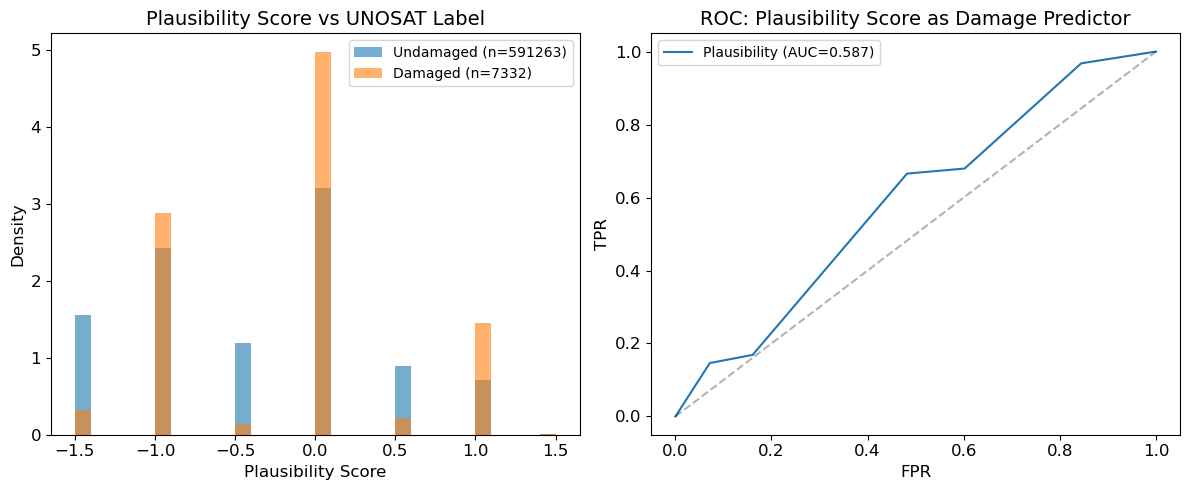

  Plot: cell_l2b/plausibility_standalone_roc_20260425_003253.png


In [7]:
# @title CELL L2b: STANDALONE PLAUSIBILITY SIGNALS vs UNOSAT
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

print("=" * 70)
print("CELL L2b: STANDALONE PLAUSIBILITY SIGNALS vs UNOSAT")
print("=" * 70)

y_true_all = PER_BUILDING_SIGNALS[TARGET_COL].values

if not SIGNAL_REGISTRY:
    print("  No plausibility signals registered. Run L1/L1b/L2 first.")
else:
    print(f"\n  Evaluating {len(SIGNAL_REGISTRY)} signals vs UNOSAT:")
    print(f"  n_buildings={len(PER_BUILDING_SIGNALS)}, damage_rate={y_true_all.mean():.3f}\n")
    print(f"  {'Signal':40s} {'AUC':>7s} {'AP':>7s} {'MWU-p':>10s} {'dmg_med':>9s} {'und_med':>9s} {'d_med':>8s}")
    print(f"  {'-'*40} {'-'*7} {'-'*7} {'-'*10} {'-'*9} {'-'*9} {'-'*8}")

    rows = []
    for col, info in SIGNAL_REGISTRY.items():
        if col not in PER_BUILDING_SIGNALS.columns:
            continue
        vals = PER_BUILDING_SIGNALS[col].values
        res = score_signal(vals, y_true_all, col, higher_is_damage=info['higher_is_damage'])
        if res is None:
            print(f"  {info['description'][:40]:40s} -- (insufficient data)")
            continue
        desc = info['description']
        print(f"  {desc[:40]:40s} {res['auc']:7.3f} {res['avg_precision']:7.3f} "
              f"{res['mwu_pvalue']:10.2e} {res['damaged_median']:9.4f} "
              f"{res['undamaged_median']:9.4f} {res['delta_median']:+8.4f}")
        rows.append({
            'signal': col, 'description': desc,
            'higher_is_damage': info['higher_is_damage'],
            'auc': res['auc'], 'avg_precision': res['avg_precision'],
            'mwu_pvalue': res['mwu_pvalue'],
            'damaged_median': res['damaged_median'],
            'undamaged_median': res['undamaged_median'],
            'delta_median': res['delta_median'],
            'n_valid': res['n_valid'],
        })
        registry.log_experiment(
            cell_id='cell_l2b',
            experiment_name=f'plausibility_standalone_{col}',
            parquet_name='bda_plausibility_v2',
            tier_selection=_tiers,
            classifier_name=f'signal_{col}',
            feature_set_name=col, feature_cols=[col],
            cv_method='none', n_folds=0, imputation='none',
            y_true=res['y_true_valid'], y_proba=res['score_for_auc'],
            groups=PER_BUILDING_SIGNALS.loc[res['mask'], 'city'].values,
            note=f'Standalone plausibility signal vs UNOSAT: {desc}',
            tags=['plausibility', 'standalone', 'experimental'],
        )
        save_oof_unsupervised(
            building_ids=PER_BUILDING_SIGNALS.loc[res['mask'], 'building_id'].values,
            cities=PER_BUILDING_SIGNALS.loc[res['mask'], 'city'].values,
            y_true=res['y_true_valid'], scores=res['score_for_auc'],
            model_id=f'L2b_{col}',
            variant_id=f'plausibility_standalone;signal={col};higher_is_damage={info["higher_is_damage"]}',
        )

    if rows:
        signal_df = pd.DataFrame(rows).sort_values('auc', ascending=False)
        save_result(signal_df, 'plausibility_standalone_vs_unosat', 'cell_l2b')

        # per-city breakdown for combined plausibility_score
        if 'plausibility_score' in PER_BUILDING_SIGNALS.columns:
            print(f"\n  Per-city AUC for combined plausibility_score:")
            print(f"  {'City':25s} {'AUC':>7s} {'n':>7s} {'dmg%':>7s}")
            print(f"  {'-'*25} {'-'*7} {'-'*7} {'-'*7}")
            city_rows = []
            for city in sorted(PER_BUILDING_SIGNALS['city'].unique()):
                cdf = PER_BUILDING_SIGNALS[PER_BUILDING_SIGNALS['city'] == city]
                cm = cdf['plausibility_score'].notna()
                if cm.sum() < 20 or len(cdf.loc[cm, TARGET_COL].unique()) < 2:
                    continue
                c_auc = roc_auc_score(cdf.loc[cm, TARGET_COL], cdf.loc[cm, 'plausibility_score'])
                c_n = int(cm.sum())
                c_rate = float(cdf.loc[cm, TARGET_COL].mean())
                print(f"  {city:25s} {c_auc:7.3f} {c_n:7d} {100*c_rate:6.1f}%")
                city_rows.append({'city': city, 'auc': round(c_auc, 4),
                                   'n': c_n, 'damage_rate': round(c_rate, 4)})
            if city_rows:
                save_result(pd.DataFrame(city_rows), 'plausibility_per_city_auc', 'cell_l2b')

    # distribution + ROC plot
    if 'plausibility_score' in PER_BUILDING_SIGNALS.columns:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        ax = axes[0]
        dmg_s = PER_BUILDING_SIGNALS.loc[PER_BUILDING_SIGNALS[TARGET_COL] == 1, 'plausibility_score'].dropna()
        und_s = PER_BUILDING_SIGNALS.loc[PER_BUILDING_SIGNALS[TARGET_COL] == 0, 'plausibility_score'].dropna()
        ax.hist(und_s, bins=30, alpha=0.6, label=f'Undamaged (n={len(und_s)})', density=True)
        ax.hist(dmg_s, bins=30, alpha=0.6, label=f'Damaged (n={len(dmg_s)})', density=True)
        ax.set_xlabel('Plausibility Score')
        ax.set_ylabel('Density')
        ax.set_title('Plausibility Score vs UNOSAT Label')
        ax.legend()

        ax2 = axes[1]
        mask_ps = PER_BUILDING_SIGNALS['plausibility_score'].notna()
        if mask_ps.sum() > 50:
            fpr, tpr, _ = roc_curve(PER_BUILDING_SIGNALS.loc[mask_ps, TARGET_COL],
                                     PER_BUILDING_SIGNALS.loc[mask_ps, 'plausibility_score'])
            auc_ps = roc_auc_score(PER_BUILDING_SIGNALS.loc[mask_ps, TARGET_COL],
                                    PER_BUILDING_SIGNALS.loc[mask_ps, 'plausibility_score'])
            ax2.plot(fpr, tpr, label=f'Plausibility (AUC={auc_ps:.3f})')
            ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3)
            ax2.set_xlabel('FPR')
            ax2.set_ylabel('TPR')
            ax2.set_title('ROC: Plausibility Score as Damage Predictor')
            ax2.legend()
        plt.tight_layout()
        save_fig(fig, 'plausibility_standalone_roc', 'cell_l2b')

# CELL L3: PLAUSIBILITY vs ALL MODELS (NB13 CONTEXT)Compares plausibility AUC against ALL NB13 registered experiments. Reads CSV, no parquet load.

In [8]:
# @title CELL L3: PLAUSIBILITY vs ALL MODELS (NB13 CONTEXT)
print("=" * 70)
print("CELL L3: PLAUSIBILITY vs ALL MODELS (NB13 CONTEXT)")
print("=" * 70)

plaus_auc = None
if 'plausibility_score' in PER_BUILDING_SIGNALS.columns:
    mask_ps = PER_BUILDING_SIGNALS['plausibility_score'].notna() & (PER_BUILDING_SIGNALS[TARGET_COL] >= 0)
    if mask_ps.sum() > 50 and len(PER_BUILDING_SIGNALS.loc[mask_ps, TARGET_COL].unique()) == 2:
        plaus_auc = roc_auc_score(PER_BUILDING_SIGNALS.loc[mask_ps, TARGET_COL],
                                   PER_BUILDING_SIGNALS.loc[mask_ps, 'plausibility_score'])
        print(f"  Plausibility score AUC (standalone vs UNOSAT): {plaus_auc:.4f}")

if NB13_DF is not None and 'auc' in NB13_DF.columns:
    df_models = NB13_DF[NB13_DF['auc'].notna()].copy()
    if 'is_reference' in df_models.columns:
        df_models = df_models[~df_models['is_reference'].fillna(False).astype(bool)]

    print(f"\n  NB13 model landscape ({len(df_models)} experiments with AUC):")
    print(f"  {'Notebook':10s} {'Experiment':45s} {'AUC':>7s} {'Classifier':>15s}")
    print(f"  {'-'*10} {'-'*45} {'-'*7} {'-'*15}")

    for _, row in df_models.sort_values('auc', ascending=False).head(20).iterrows():
        marker = ""
        if plaus_auc is not None and row['auc'] < plaus_auc:
            marker = " << BELOW plausibility"
        print(f"  {str(row.get('notebook','')):10s} {str(row.get('experiment_name',''))[:45]:45s} "
              f"{row['auc']:7.4f} {str(row.get('classifier_name','')):>15s}{marker}")

    if plaus_auc is not None:
        n_below = int((df_models['auc'] < plaus_auc).sum())
        n_above = int((df_models['auc'] > plaus_auc).sum())
        pct_below = 100 * n_below / len(df_models) if len(df_models) > 0 else 0
        print(f"\n  Plausibility score (AUC={plaus_auc:.4f}) beats {n_below}/{len(df_models)} "
              f"({pct_below:.0f}%) of registered ML experiments")
        print(f"  Models above plausibility: {n_above}")

    print(f"\n  Best per notebook vs plausibility:")
    for nb_name in sorted(df_models['notebook'].dropna().unique()):
        nb_sub = df_models[df_models['notebook'] == nb_name]
        if nb_sub['auc'].notna().any():
            best_row = nb_sub.loc[nb_sub['auc'].idxmax()]
            delta = ""
            if plaus_auc is not None:
                d = best_row['auc'] - plaus_auc
                delta = f"  (vs plausibility: {d:+.4f})"
            print(f"    {nb_name:10s}: AUC={best_row['auc']:.4f} ({best_row.get('experiment_name','?')}){delta}")

    save_result(df_models[['notebook', 'experiment_name', 'auc', 'f1', 'classifier_name',
                           'feature_set_name', 'cv_method']].head(30),
                'model_landscape_top30', 'cell_l3')
else:
    print("  NB13 consolidated CSV not available. Run NB13 first.")

if NB08A_ABLATION is not None and 'auc' in NB08A_ABLATION.columns:
    print(f"\n  NB08a ablation context:")
    print(f"  {'Tier':15s} {'Sensor':10s} {'AUC':>7s}")
    print(f"  {'-'*15} {'-'*10} {'-'*7}")
    for _, row in NB08A_ABLATION.sort_values('auc', ascending=False).head(10).iterrows():
        print(f"  {str(row.get('tier','')):15s} {str(row.get('sensor','')):10s} {row['auc']:7.3f}")
    best_abl = float(NB08A_ABLATION['auc'].max())
    if plaus_auc is not None:
        print(f"\n  Best ablation AUC={best_abl:.4f} vs plausibility AUC={plaus_auc:.4f} "
              f"(delta={best_abl - plaus_auc:+.4f})")

print(f"\n  NOTE: This cell provides CONTEXT only. NB10 will apply plausibility")
print(f"  as post-processing on winning models selected via NB13.")

CELL L3: PLAUSIBILITY vs ALL MODELS (NB13 CONTEXT)
  Plausibility score AUC (standalone vs UNOSAT): 0.5867

  NB13 model landscape (180 experiments with AUC):
  Notebook   Experiment                                        AUC      Classifier
  ---------- --------------------------------------------- ------- ---------------
  NB09d      xbd_on_xbd                                     0.9643           U-Net
  NB08c_v2   C_F3_fusion_card_cohdrop                       0.8578 LightGBM-300-MIA
  NB08c_v2   C_F2_fusion_ms_card_cohdrop                    0.8551 LightGBM-300-MIA
  NB08c_v2   C_A15_block_stats                              0.8433 LightGBM-300-MIA
  NB08c_v2   C_F8_fusion_composite_blockstats               0.8420 LightGBM-300-MIA
  NB08c_v2   C_F4_fusion_ms_cohdrop                         0.8347 LightGBM-300-MIA
  NB08c_v2   C_F6_fusion_indices_card_cohdrop               0.8329 LightGBM-300-MIA
  NB08c_v2   C_A17_rolling_stats_roll7                      0.8302 LightGBM-300-MIA
  NB

# CELL L4: NDVI CHANGE ANALYSIS (v2 from A5 scene_indices, computed in L2)Distribution plots + per-city breakdown of NDVI delta.NDVI delta was computed in L2 via A5 long->wide pre/post aggregation.

CELL L4: NDVI CHANGE ANALYSIS


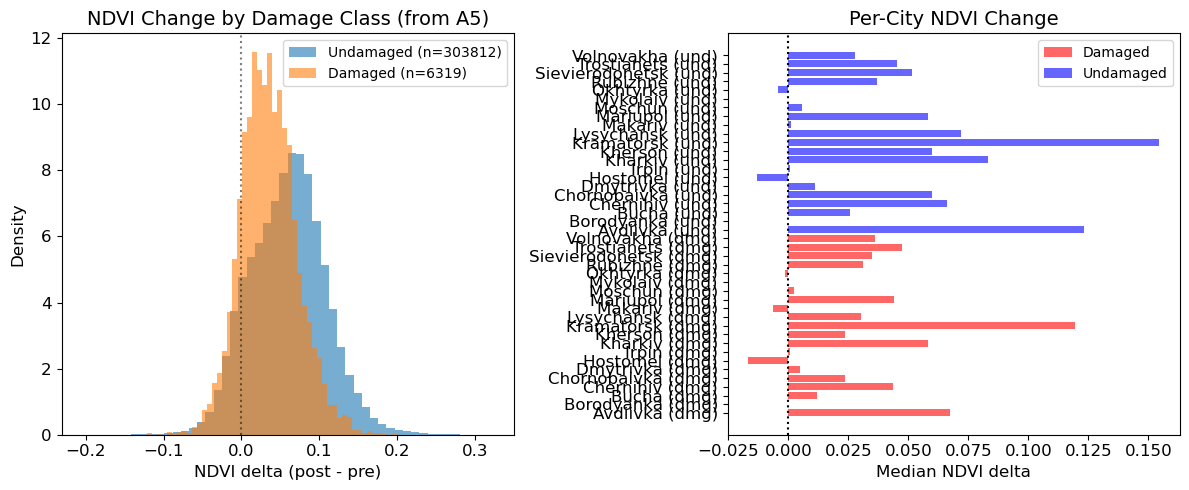

  Plot: cell_l4/ndvi_change_analysis_20260425_003256.png
  Mann-Whitney U: stat=651371760, p=0.00e+00
  Damaged median NDVI delta: 0.0333
  Undamaged median NDVI delta: 0.0606
  REG: L4_ndvi_delta_standalone                      AUC=0.6607 F1=0.0000 n=310131 feat=1 cities=19 [NB09e_v2/cell_l4]
  Registered ndvi_delta to NB13 registry


In [9]:
# @title CELL L4: NDVI CHANGE ANALYSIS
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

print("=" * 70)
print("CELL L4: NDVI CHANGE ANALYSIS")
print("=" * 70)

if 'ndvi_delta' in PER_BUILDING_SIGNALS.columns and PER_BUILDING_SIGNALS['ndvi_delta'].notna().sum() > 100:
    dmg = PER_BUILDING_SIGNALS[PER_BUILDING_SIGNALS[TARGET_COL] == 1]['ndvi_delta'].dropna()
    und = PER_BUILDING_SIGNALS[PER_BUILDING_SIGNALS[TARGET_COL] == 0]['ndvi_delta'].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax = axes[0]
    ax.hist(und, bins=50, alpha=0.6, label=f'Undamaged (n={len(und)})', density=True)
    ax.hist(dmg, bins=50, alpha=0.6, label=f'Damaged (n={len(dmg)})', density=True)
    ax.axvline(0, color='k', linestyle=':', alpha=0.5)
    ax.set_xlabel('NDVI delta (post - pre)')
    ax.set_ylabel('Density')
    ax.set_title('NDVI Change by Damage Class (from A5)')
    ax.legend()

    ax2 = axes[1]
    cities = sorted(PER_BUILDING_SIGNALS['city'].unique())
    city_dmg = []
    city_und = []
    for city in cities:
        cdf = PER_BUILDING_SIGNALS[PER_BUILDING_SIGNALS['city'] == city]
        city_dmg.append(cdf[cdf[TARGET_COL] == 1]['ndvi_delta'].median())
        city_und.append(cdf[cdf[TARGET_COL] == 0]['ndvi_delta'].median())
    ax2.barh([f"{c} (dmg)" for c in cities], city_dmg, color='red', alpha=0.6, label='Damaged')
    ax2.barh([f"{c} (und)" for c in cities], city_und, color='blue', alpha=0.6, label='Undamaged')
    ax2.axvline(0, color='k', linestyle=':')
    ax2.set_xlabel('Median NDVI delta')
    ax2.set_title('Per-City NDVI Change')
    ax2.legend()
    plt.tight_layout()
    save_fig(fig, 'ndvi_change_analysis', 'cell_l4')

    if len(dmg) > 10 and len(und) > 10:
        stat, pval = mannwhitneyu(dmg, und, alternative='two-sided')
        print(f"  Mann-Whitney U: stat={stat:.0f}, p={pval:.2e}")
        print(f"  Damaged median NDVI delta: {dmg.median():.4f}")
        print(f"  Undamaged median NDVI delta: {und.median():.4f}")

        # register ndvi_delta
        ndvi_mask = PER_BUILDING_SIGNALS['ndvi_delta'].notna() & (PER_BUILDING_SIGNALS[TARGET_COL] >= 0)
        if ndvi_mask.sum() > 50 and len(PER_BUILDING_SIGNALS.loc[ndvi_mask, TARGET_COL].unique()) == 2:
            registry.log_experiment(
                cell_id='cell_l4',
                experiment_name='L4_ndvi_delta_standalone',
                parquet_name='bda_scene_indices_v2',
                tier_selection=_tiers,
                classifier_name='signal_ndvi_delta',
                feature_set_name='ndvi_delta', feature_cols=['ndvi_delta'],
                cv_method='none', n_folds=0, imputation='none',
                y_true=PER_BUILDING_SIGNALS.loc[ndvi_mask, TARGET_COL].values,
                y_proba=-PER_BUILDING_SIGNALS.loc[ndvi_mask, 'ndvi_delta'].values,
                groups=PER_BUILDING_SIGNALS.loc[ndvi_mask, 'city'].values,
                note='NDVI delta as standalone damage predictor (sign-flipped: negative delta = damage)',
                tags=['plausibility', 'ndvi', 'standalone', 'A5'],
            )
            print(f"  Registered ndvi_delta to NB13 registry")
else:
    print(f"  No NDVI delta data available (was computed in L2)")

# CELL L4b: MS SWIR + MAHALANOBIS ACCUMULATOR SIGNALS (v2 A20 + A21)NEW cells from NB03e accumulators. Evaluates accumulator-derived MS signals:**A20 ms_change** (SWIR rise + NBR anomaly):- `swir_rise_count_mean`: number of scenes where SWIR exceeded baseline (damage = many rises)- `swir_z_running_max_mean`: peak z-score (damage = high z)- `nbr_anomaly_count_mean`: number of NBR anomalies (damage = many)- `date_first_swir_rise_mean`: timing (earlier = damage during battle)**A21 ms_maha** (Mahalanobis distance):- `mahalanobis_running_max_mean`: peak distance (damage = high)- `mahalanobis_exceedance_count_mean`: exceedance count (damage = many)- `date_first_exceedance_mean`: timing (earlier = damage)

In [10]:
# @title CELL L4b: MS SWIR + MAHALANOBIS ACCUMULATOR SIGNALS (A20 + A21)
print("=" * 70)
print("CELL L4b: MS ACCUMULATOR SIGNALS")
print("=" * 70)

A20_SIGNALS = [
    ('s2__swir_rise_count_mean',          True, 'A20 SWIR: rise count mean (more rises = damage)'),
    ('s2__swir_z_running_max_mean',       True, 'A20 SWIR: z-running max mean (peak anomaly = damage)'),
    ('s2__nbr_anomaly_count_mean',        True, 'A20 NBR: anomaly count mean (more anomalies = damage)'),
    ('s2__date_first_swir_rise_mean',     True, 'A20 SWIR: date first rise (earlier = damage during battle)'),
    ('s2__date_worst_swir_rise_mean',     True, 'A20 SWIR: date worst rise (earlier = damage)'),
]
A21_SIGNALS = [
    ('s2__mahalanobis_running_max_mean',     True, 'A21 Mahalanobis: running max mean (peak = damage)'),
    ('s2__mahalanobis_exceedance_count_mean', True, 'A21 Mahalanobis: exceedance count mean (more = damage)'),
    ('s2__date_first_exceedance_mean',       True, 'A21 Mahalanobis: date first exceedance (earlier = damage)'),
]

rows = []
y_true_all = PER_BUILDING_SIGNALS[TARGET_COL].values

# ---- A20 ms_change ----
print(f"\n  --- A20 ms_change ---")
try:
    df_msc = load_v2('ms_change')
    cols_want = [c for c, _, _ in A20_SIGNALS if c in df_msc.columns]
    if cols_want:
        df_slim = df_msc[['building_id', 'city'] + cols_want].drop_duplicates(['building_id', 'city'])
        pb = PER_BUILDING_SIGNALS[['building_id', 'city']].merge(
            df_slim, on=['building_id', 'city'], how='left')
        print(f"  {'Signal':55s} {'AUC':>7s} {'AP':>7s} {'MWU-p':>10s} {'n':>7s}")
        print(f"  {'-'*55} {'-'*7} {'-'*7} {'-'*10} {'-'*7}")
        for col, higher_is_damage, desc in A20_SIGNALS:
            if col not in pb.columns:
                continue
            vals = pb[col].values.astype(float)
            res = score_signal(vals, y_true_all, col, higher_is_damage=higher_is_damage)
            if res is None:
                continue
            print(f"  {desc:55s} {res['auc']:7.3f} {res['avg_precision']:7.3f} {res['mwu_pvalue']:10.2e} {res['n_valid']:7d}")
            rows.append({
                'signal': col, 'description': desc, 'parquet': 'ms_change_A20',
                'higher_is_damage': higher_is_damage,
                'auc': res['auc'], 'avg_precision': res['avg_precision'],
                'mwu_pvalue': res['mwu_pvalue'],
                'damaged_median': res['damaged_median'],
                'undamaged_median': res['undamaged_median'],
                'delta_median': res['delta_median'],
                'n_valid': res['n_valid'],
            })
            add_signal(col, pb[col], higher_is_damage, desc)
            registry.log_experiment(
                cell_id='cell_l4b',
                experiment_name=f'L4b_accumulator_{col}',
                parquet_name='bda_ms_change_v2',
                tier_selection=_tiers,
                classifier_name=f'signal_{col}',
                feature_set_name=col, feature_cols=[col],
                cv_method='none', n_folds=0, imputation='none',
                y_true=res['y_true_valid'], y_proba=res['score_for_auc'],
                groups=pb.loc[res['mask'], 'city'].values,
                note=f'A20 ms_change accumulator standalone signal: {desc}',
                tags=['plausibility', 'ms', 'accumulator', 'standalone'],
            )
    del df_msc
    gc.collect()
except (FileNotFoundError, KeyError) as e:
    print(f"  SKIP A20: {e}")

# ---- A21 ms_maha ----
print(f"\n  --- A21 ms_maha ---")
try:
    df_maha = load_v2('ms_maha')
    cols_want = [c for c, _, _ in A21_SIGNALS if c in df_maha.columns]
    if cols_want:
        df_slim = df_maha[['building_id', 'city'] + cols_want].drop_duplicates(['building_id', 'city'])
        pb = PER_BUILDING_SIGNALS[['building_id', 'city']].merge(
            df_slim, on=['building_id', 'city'], how='left')
        print(f"  {'Signal':55s} {'AUC':>7s} {'AP':>7s} {'MWU-p':>10s} {'n':>7s}")
        print(f"  {'-'*55} {'-'*7} {'-'*7} {'-'*10} {'-'*7}")
        for col, higher_is_damage, desc in A21_SIGNALS:
            if col not in pb.columns:
                continue
            vals = pb[col].values.astype(float)
            res = score_signal(vals, y_true_all, col, higher_is_damage=higher_is_damage)
            if res is None:
                continue
            print(f"  {desc:55s} {res['auc']:7.3f} {res['avg_precision']:7.3f} {res['mwu_pvalue']:10.2e} {res['n_valid']:7d}")
            rows.append({
                'signal': col, 'description': desc, 'parquet': 'ms_maha_A21',
                'higher_is_damage': higher_is_damage,
                'auc': res['auc'], 'avg_precision': res['avg_precision'],
                'mwu_pvalue': res['mwu_pvalue'],
                'damaged_median': res['damaged_median'],
                'undamaged_median': res['undamaged_median'],
                'delta_median': res['delta_median'],
                'n_valid': res['n_valid'],
            })
            add_signal(col, pb[col], higher_is_damage, desc)
            registry.log_experiment(
                cell_id='cell_l4b',
                experiment_name=f'L4b_accumulator_{col}',
                parquet_name='bda_ms_maha_v2',
                tier_selection=_tiers,
                classifier_name=f'signal_{col}',
                feature_set_name=col, feature_cols=[col],
                cv_method='none', n_folds=0, imputation='none',
                y_true=res['y_true_valid'], y_proba=res['score_for_auc'],
                groups=pb.loc[res['mask'], 'city'].values,
                note=f'A21 ms_maha accumulator standalone signal: {desc}',
                tags=['plausibility', 'ms', 'accumulator', 'standalone'],
            )
    del df_maha
    gc.collect()
except (FileNotFoundError, KeyError) as e:
    print(f"  SKIP A21: {e}")

if rows:
    accum_df = pd.DataFrame(rows).sort_values('auc', ascending=False)
    save_result(accum_df, 'ms_accumulator_signals', 'cell_l4b')
    print(f"\n  Top-3 MS accumulator signals:")
    for _, row in accum_df.head(3).iterrows():
        print(f"    {row['description'][:60]:60s} AUC={row['auc']:.3f}")

CELL L4b: MS ACCUMULATOR SIGNALS

  --- A20 ms_change ---
  load_v2('ms_change'): 598,595 rows, 29 cols, 21 cities
  Signal                                                      AUC      AP      MWU-p       n
  ------------------------------------------------------- ------- ------- ---------- -------
  A20 SWIR: z-running max mean (peak anomaly = damage)      0.501   0.002   1.23e-09  325901
  REG: L4b_accumulator_s2__swir_z_running_max_mean   AUC=0.5011 F1=0.0000 n=325901 feat=1 cities=6 [NB09e_v2/cell_l4b]
  A20 SWIR: date worst rise (earlier = damage)              0.500   0.001   9.58e-01  325901
  REG: L4b_accumulator_s2__date_worst_swir_rise_mean AUC=0.5000 F1=0.0027 n=325901 feat=1 cities=6 [NB09e_v2/cell_l4b]

  --- A21 ms_maha ---
  load_v2('ms_maha'): 598,595 rows, 20 cols, 21 cities
  Signal                                                      AUC      AP      MWU-p       n
  ------------------------------------------------------- ------- ------- ---------- -------
  A21 Mahal

# CELL L5: GROUND TRUTH PLAUSIBILITY ANALYSISAnalyze consistency between UNOSAT labels and computed plausibility signals.No ML — purely descriptive. Uses PER_BUILDING_SIGNALS populated by L1/L1b/L2/L4b.

In [11]:
# @title CELL L5: GROUND TRUTH PLAUSIBILITY ANALYSIS
print("=" * 70)
print("CELL L5: GROUND TRUTH PLAUSIBILITY ANALYSIS")
print("=" * 70)

df_gt = PER_BUILDING_SIGNALS[PER_BUILDING_SIGNALS[TARGET_COL] >= 0].copy()
damaged = df_gt[df_gt[TARGET_COL] == 1]
undamaged = df_gt[df_gt[TARGET_COL] == 0]

print(f"  Total: {len(df_gt)} buildings ({len(damaged)} damaged, {len(undamaged)} undamaged)")

# --- UNOSAT-damaged buildings with implausible characteristics ---
print(f"\n  DAMAGED buildings (UNOSAT=1) with IMPLAUSIBLE characteristics:")
n_checks = 0

if 'lu_transition' in damaged.columns:
    dmg_implausible = int(damaged['lu_implausible_damage'].sum()) if 'lu_implausible_damage' in damaged.columns else 0
    dmg_plausible = int(damaged['lu_plausible_damage'].sum()) if 'lu_plausible_damage' in damaged.columns else 0
    print(f"    Landuse: {dmg_plausible} plausible, {dmg_implausible} implausible transitions")
    if len(damaged) > 0:
        print(f"    -> {100*dmg_implausible/len(damaged):.1f}% of damaged buildings have implausible landuse transition")

    print(f"\n    Top landuse transitions for DAMAGED buildings:")
    trans_dmg = damaged['lu_transition'].value_counts().head(10)
    for trans, count in trans_dmg.items():
        pct = 100 * count / len(damaged)
        print(f"      {trans:35s}: {count:5d} ({pct:.1f}%)")
    n_checks += 1

if 'ndvi_delta' in damaged.columns and damaged['ndvi_delta'].notna().sum() > 10:
    dmg_ndvi_pos = int((damaged['ndvi_delta'] > 0.05).sum())
    print(f"\n    NDVI: {dmg_ndvi_pos} damaged buildings have NDVI INCREASE (>0.05)")
    print(f"    -> {100*dmg_ndvi_pos/len(damaged):.1f}% unexpected (vegetation grew on damaged site?)")
    n_checks += 1

if 'coh_drop' in damaged.columns and damaged['coh_drop'].notna().sum() > 10:
    coh_higher_is_damage = SIGNAL_REGISTRY.get('coh_drop', {}).get('higher_is_damage', True)
    if coh_higher_is_damage:
        dmg_coh_no_change = int((damaged['coh_drop'] < 0).sum())
    else:
        dmg_coh_no_change = int((damaged['coh_drop'] > 0).sum())
    coh_valid = int(damaged['coh_drop'].notna().sum())
    print(f"\n    COH: {dmg_coh_no_change}/{coh_valid} damaged buildings have non-damage COH direction")
    print(f"    -> {100*dmg_coh_no_change/coh_valid:.1f}% inconsistent with structural damage")
    n_checks += 1

if 'area_m2' in damaged.columns:
    dmg_small = int((damaged['area_m2'] < 50).sum())
    print(f"\n    Size: {dmg_small} damaged buildings < 50 m2 ({100*dmg_small/len(damaged):.1f}%)")
    print(f"    -> unreliable at 10m resolution")
    n_checks += 1

# --- UNOSAT-undamaged buildings with damage-like characteristics ---
print(f"\n  UNDAMAGED buildings (UNOSAT=0) with DAMAGE-LIKE characteristics:")

if 'lu_plausible_damage' in undamaged.columns:
    und_plausible = int(undamaged['lu_plausible_damage'].sum())
    if len(undamaged) > 0:
        print(f"    Landuse: {und_plausible} undamaged buildings have plausible-damage transitions")
        print(f"    -> {100*und_plausible/len(undamaged):.1f}% potential UNOSAT false negatives (Aimaiti 2022)")

if 'ndvi_delta' in undamaged.columns and undamaged['ndvi_delta'].notna().sum() > 10:
    und_ndvi_drop = int((undamaged['ndvi_delta'] < -0.1).sum())
    print(f"    NDVI: {und_ndvi_drop} undamaged buildings have significant NDVI drop")
    if len(undamaged) > 0:
        print(f"    -> {100*und_ndvi_drop/len(undamaged):.1f}% potential missed damage")

if 'coh_drop' in undamaged.columns and undamaged['coh_drop'].notna().sum() > 10:
    coh_thresh = df_gt['coh_drop'].quantile(0.75)
    und_coh_high = int((undamaged['coh_drop'] > coh_thresh).sum())
    coh_valid = int(undamaged['coh_drop'].notna().sum())
    print(f"    COH: {und_coh_high}/{coh_valid} undamaged buildings have high COH drop (>p75={coh_thresh:.3f})")
    if coh_valid > 0:
        print(f"    -> {100*und_coh_high/coh_valid:.1f}% potential missed damage")

# --- Accumulator signals on UNOSAT=0 (potential missed damage) ---
print(f"\n  Accumulator signals on UNDAMAGED buildings (potential missed damage):")
for col in ['s2__swir_rise_count_mean', 's2__mahalanobis_running_max_mean',
             's2__lu__loss_fraction_mean']:
    if col in undamaged.columns and undamaged[col].notna().sum() > 10:
        thresh = df_gt[col].quantile(0.90)
        und_high = int((undamaged[col] > thresh).sum())
        und_valid = int(undamaged[col].notna().sum())
        print(f"    {col:55s}: {und_high}/{und_valid} above p90={thresh:.3f}")

# --- per-city plausibility consistency ---
if 'plausibility_score' in df_gt.columns:
    print(f"\n  Per-city plausibility consistency:")
    print(f"  {'City':25s} {'n_dmg':>7s} {'n_und':>7s} {'dmg_plaus':>10s} {'und_plaus':>10s} {'consist%':>9s}")
    print(f"  {'-'*25} {'-'*7} {'-'*7} {'-'*10} {'-'*10} {'-'*9}")
    city_consist = []
    for city in sorted(df_gt['city'].unique()):
        cdf = df_gt[df_gt['city'] == city]
        c_dmg = cdf[cdf[TARGET_COL] == 1]
        c_und = cdf[cdf[TARGET_COL] == 0]
        dmg_consistent = int((c_dmg['plausibility_score'] > 0).sum()) if len(c_dmg) > 0 else 0
        und_consistent = int((c_und['plausibility_score'] <= 0).sum()) if len(c_und) > 0 else 0
        total = len(c_dmg) + len(c_und)
        consist_pct = 100 * (dmg_consistent + und_consistent) / total if total > 0 else 0
        print(f"  {city:25s} {len(c_dmg):7d} {len(c_und):7d} "
              f"{dmg_consistent:10d} {und_consistent:10d} {consist_pct:8.1f}%")
        city_consist.append({
            'city': city, 'n_damaged': len(c_dmg), 'n_undamaged': len(c_und),
            'dmg_consistent': dmg_consistent, 'und_consistent': und_consistent,
            'consistency_pct': round(consist_pct, 1),
        })
    if city_consist:
        save_result(pd.DataFrame(city_consist), 'plausibility_consistency_per_city', 'cell_l5')

if n_checks > 0:
    print(f"\n  THESIS IMPLICATION: UNOSAT labels have measurable inconsistencies with")
    print(f"  physical plausibility signals. Supports Aimaiti 2022 finding that UNOSAT")
    print(f"  underreports damage. Plausibility + accumulator signals can flag potential")
    print(f"  false negatives for review in NB10 operational pipeline.")

CELL L5: GROUND TRUTH PLAUSIBILITY ANALYSIS
  Total: 598595 buildings (7332 damaged, 591263 undamaged)

  DAMAGED buildings (UNOSAT=1) with IMPLAUSIBLE characteristics:
    Landuse: 1217 plausible, 2354 implausible transitions
    -> 32.1% of damaged buildings have implausible landuse transition

    Top landuse transitions for DAMAGED buildings:
      sparse_veg -> sparse_veg           :  2046 (27.9%)
      urban -> urban                     :  1695 (23.1%)
      urban -> sparse_veg                :   942 (12.8%)
      bare_soil -> sparse_veg            :   859 (11.7%)
      bare_soil -> urban                 :   458 (6.2%)
      bare_soil -> bare_soil             :   294 (4.0%)
      sparse_veg -> urban                :   274 (3.7%)
      urban -> bare_soil                 :   258 (3.5%)
      sparse_veg -> vegetation           :   117 (1.6%)
      sparse_veg -> bare_soil            :    94 (1.3%)

    NDVI: 2040 damaged buildings have NDVI INCREASE (>0.05)
    -> 27.8% unexpected (v

# CELL L6: NB09e v2 SUMMARY + SAVE REGISTRY

In [12]:
# @title CELL L6: NB09e v2 SUMMARY + SAVE REGISTRY
print("=" * 70)
print("NB09e v2 PLAUSIBILITY FILTER SUMMARY")
print("=" * 70)

print(f"\n  Data sources (v2 manifest + NB03e accumulators):")
print(f"    A10 composite_prepost_landuse -> pre/post landuse mode per building")
print(f"    A5  scene_indices             -> NDVI via battle-date aggregation")
print(f"    A14 coh_drop                  -> derived COH drop stats")
print(f"    A20 ms_change                 -> SWIR z + NBR anomaly accumulator (NEW)")
print(f"    A21 ms_maha                   -> Mahalanobis distance accumulator (NEW)")
print(f"    A22 lu_change                 -> persistent urban landuse loss accumulator (NEW)")
print(f"    bda_buildings_t{{tier}}         -> labels + area_m2")

print(f"\n  Plausibility signals evaluated vs UNOSAT:")
for col, info in SIGNAL_REGISTRY.items():
    desc = info['description']
    print(f"    {col:55s} - {desc}")

print(f"\n  Key outputs:")
print(f"    L1  - Landuse transition matrix + plausible/implausible binary signals")
print(f"    L1b - A22 persistent urban loss accumulator signals (NEW)")
print(f"    L2  - Combined plausibility_score")
print(f"    L2b - Standalone AUC/AP/MWU per signal")
print(f"    L3  - NB13 model landscape context")
print(f"    L4  - NDVI distribution + per-city breakdown")
print(f"    L4b - A20 SWIR + A21 Mahalanobis accumulator signals (NEW)")
print(f"    L5  - UNOSAT label consistency analysis (damage + accumulator signals)")

print(f"\n  DESIGN DECISION (v2 vs v9):")
print(f"    Previous v9 used bda_product_prepost + regex-guessing of column names.")
print(f"    v2 uses manifest-driven v2 parquets directly + NB03e accumulators.")
print(f"    Plausibility signals now include temporal-integration accumulators,")
print(f"    not just pre/post snapshots. Expected to carry more damage signal for")
print(f"    cities with good observation density.")

print(f"\n  FUTURE (NB10 series):")
print(f"    NB10 applies plausibility as post-processing on winning NB13 models.")

try:
    registry.save()
    print(f"\n  Registry saved to {RESULTS_ROOT / 'registry'}")
except Exception as e:
    print(f"  registry.save() error: {e}")

# save PER_BUILDING_SIGNALS so downstream NB10 can use them
pbs_out = OUT_DIR / 'per_building_signals.parquet'
PER_BUILDING_SIGNALS.to_parquet(pbs_out, index=False)
print(f"  Per-building signals parquet: {pbs_out} ({pbs_out.stat().st_size / 1024:.1f} KB)")

# ---- OOF predictions inventory (for NB12 overlap analysis) ----
print(f"\n  OOF predictions inventory  ({OOF_DIR})")
oof_files = sorted(OOF_DIR.glob('oof_*.parquet'))
if oof_files:
    inv_rows = []
    for p in oof_files:
        head = pd.read_parquet(p, columns=['model_id', 'variant_id', 'cm_class'])
        cm = head['cm_class'].value_counts()
        inv_rows.append({
            'file':       p.name,
            'model_id':   head['model_id'].iloc[0],
            'variant_id': head['variant_id'].iloc[0],
            'n_rows':     len(head),
            'TP':         int(cm.get('TP', 0)),
            'FN':         int(cm.get('FN', 0)),
            'FP':         int(cm.get('FP', 0)),
            'TN':         int(cm.get('TN', 0)),
        })
    inv_df = pd.DataFrame(inv_rows)
    save_result(inv_df, 'nb09e_oof_inventory', 'cell_l6')
    print(f"  Total OOF parquets: {len(oof_files)}")
else:
    print(f"  No OOF parquets saved")

NB09e v2 PLAUSIBILITY FILTER SUMMARY

  Data sources (v2 manifest + NB03e accumulators):
    A10 composite_prepost_landuse -> pre/post landuse mode per building
    A5  scene_indices             -> NDVI via battle-date aggregation
    A14 coh_drop                  -> derived COH drop stats
    A20 ms_change                 -> SWIR z + NBR anomaly accumulator (NEW)
    A21 ms_maha                   -> Mahalanobis distance accumulator (NEW)
    A22 lu_change                 -> persistent urban landuse loss accumulator (NEW)
    bda_buildings_t{tier}         -> labels + area_m2

  Plausibility signals evaluated vs UNOSAT:
    lu_plausible_damage                                     - Landuse transition urban -> bare_soil/vegetation/sparse_veg
    lu_implausible_damage                                   - Landuse transition same-class (no change = no damage)
    s2__lu__urban_retained_mean                             - LU: urban retained mean (higher = no damage)
    s2__lu__loss_fraction_me